In [2]:
!pip install enoslib ipywidgets --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [1]:
!ssh rennes.grid5000.fr hostname

frennes


In [ ]:
!ssh-add ~/.ssh/id_ed25519

.ssh/id_ed25519: No such file or directory


### G5K connection

Setup the `.python-grid5000.yaml` file with the username and password used to login to grid5000.

The file should look like this:
```yaml
username: G5K_LOGIN
password: G5K_password
```

-> required in order for the enoslib calls to g5k to work.

In addition to this, make sure to add these lines to your ssh configuration:

```text
Host g5k
    User G5K_LOGIN
    HostName access.grid5000.fr
    ForwardAgent no

Host !access.grid5000.fr *.grid5000.fr
    User G5K_LOGIN
    ProxyJump G5K_LOGIN@access.grid5000.fr
    StrictHostKeyChecking no
    UserKnownHostsFile /dev/null
    ForwardAgent yes

Host access.grid5000.fr
    User G5K_LOGIN
    StrictHostKeyChecking no
    UserKnownHostsFile /dev/null
    ForwardAgent yes

Host *.g5k
    User G5K_LOGIN
    ProxyCommand ssh g5k -W "$(basename %h .g5k):%p"
    ForwardAgent no
```

Make sure to replace `G5K_LOGIN` with your g5k username (the one from the site)

In [1]:
import os
from grid5000 import Grid5000

conf_file = os.path.join(os.environ.get("HOME"), ".python-grid5000.yaml") # type: ignore
gk = Grid5000.from_yaml(conf_file)

print("Sites: ")
display(gk.sites.list())

Sites: 


[<Site uid:bordeaux>,
 <Site uid:grenoble>,
 <Site uid:lille>,
 <Site uid:louvain>,
 <Site uid:luxembourg>,
 <Site uid:lyon>,
 <Site uid:nancy>,
 <Site uid:nantes>,
 <Site uid:rennes>,
 <Site uid:sophia>,
 <Site uid:strasbourg>,
 <Site uid:toulouse>]

### Job configuration

Setup the various parameters for the job:
- The job name will identify the current booking, if the notebook kernel dies, re running the same reservation code with the same name will reload the existing job instead of booking a new one
- The walltime is the time that the booking will last, you can always stop your reservation earlier than the booking's end time

In [3]:
JOB_NAME="fcquic_multisite_GRE_testing"
JOB_WALLTIME="2:40:00"

SERVER_CLUSTER="econome"
CLIENT_CLUSTER="parasilo"
NUM_SERVER_NODES=1
NUM_CLIENT_NODES_CLUSTER_A = 1

SUBNET_SERVER_SITE= "nantes"
SUBNET_CLIENT_SITE= "rennes"


### Create the booking

This first case will only create the booking object locally, but not yet place the booking.

You can adjust the different roles of the machines to match the roles defined in the NPF script.

For example, here I have 2 roles: server and client. The server node will run the server section of the NPF script,...

In [4]:
import enoslib as en
import logging

# Display some general information about the library
en.check()
# Enable rich logging
_ = en.init_logging()
# en.set_config(g5k_auto_jump=False)

conf = (
    en.G5kConf.from_settings(
        job_name=JOB_NAME,
        walltime=JOB_WALLTIME,
        env_name="debian12-nfs",
        job_type=["deploy"],
    ) 
    # router nodes
    .add_machine(
        roles=["router", "router_server"],
        cluster=SERVER_CLUSTER,
        nodes=1,
    ) 
    .add_machine(
        roles=["router", "router_client"],
        cluster=CLIENT_CLUSTER, 
        nodes=1,
    ) 
    # server
    .add_machine(
        roles=["server"],
        cluster=SERVER_CLUSTER,
        nodes=NUM_SERVER_NODES,
    ) 
    # client nodes
    .add_machine(
        roles=["client"],
        cluster=CLIENT_CLUSTER, 
        nodes=NUM_CLIENT_NODES_CLUSTER_A,
    )
    # subnets
    .add_network(
        id="subnet_server",
        type="slash_22",
        roles=["subnet", "subnet_server"],
        site=SUBNET_SERVER_SITE,
    ).add_network(
        id="subnet_client",
        type="slash_22",
        roles=["subnet", "subnet_client"],
        site=SUBNET_CLIENT_SITE,
    )
)

# This will validate the configuration, but not reserve resources yet
provider = en.G5k(conf)

[WARNING]: failed to patch stdout/stderr for fork-safety: 'OutStream' object
has no attribute 'buffer'
[WARNING]: failed to reconfigure stdout/stderr with custom encoding error
handler: 'OutStream' object has no attribute 'reconfigure'


_____        ___  ____  _ _ _
 | ____|_ __  / _ \/ ___|| (_) |__
 |  _| | '_ \| | | \___ \| | | '_ \
 | |___| | | | |_| |___) | | | |_) |
 |_____|_| |_|\___/|____/|_|_|_.__/  10.6.0

 • Documentation: ]8;id=395151;https://discovery.gitlabpages.inria.fr/enoslib/\https://discovery.gitlabpages.inria.fr/enoslib/]8;;\                            
 • Source: ]8;id=270549;https://gitlab.inria.fr/discovery/enoslib\https://gitlab.inria.fr/discovery/enoslib]8;;\                                         
 • Chat: ]8;id=930914;https://framateam.org/enoslib\https://framateam.org/enoslib]8;;\

                         Dependency check                         
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Provider      ┃    Status     ┃ Hint                           ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Chameleon     │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ ChameleonKVM  │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ ChameleonEdge │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ Fabric        │ NOT INSTALLED │ pip install enoslib[fabric]    │
│ Distem        │ NOT INSTALLED │ pip install enoslib[distem]    │
│ IOT-lab       │ NOT INSTALLED │ pip install enoslib[iotlab]    │
│ Grid'5000     │   INSTALLED   │                                │
│ Openstack     │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ Vagrant       │ NOT INSTALLED │ pip install enoslib[vagrant]   │
│ VMonG5k       │   INSTALLED   │                                │
└───────────────┴───────────────┴────────────────────────────────┘

                                Connectivity check                                 
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Provider  ┃ Key                 ┃ Connectivity ┃ Hint                           ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Grid'5000 │ ssh:access          │      ✅      │ Connection to access.grid5000… │
│ Grid'5000 │ ssh:access:frontend │      ✅      │ Connection Host(rennes.grid50… │
│ Grid'5000 │ api:access          │      ✅      │                                │
│ VMonG5k   │ access              │      ❔      │ Check G5k status               │
└───────────┴─────────────────────┴──────────────┴────────────────────────────────┘

In [5]:
print("Reserving resources...")

# Get actual resources
roles, networks = provider.init()
display(roles)
display(networks)

# Fill in network information from nodes
roles = en.sync_info(roles, networks)

with en.actions(roles=roles, gather_facts=True) as a:
    a.apt(task_name="Install iperf", name="iperf", state="present")
    a.file(
        task_name="Ensure apt keyring directory exists",
        path="/usr/share/keyrings",
        state="directory",
        mode="0755",
    )
    a.get_url(
        task_name="Download FRR GPG key",
        url="https://deb.frrouting.org/frr/keys.gpg",
        dest="/usr/share/keyrings/frrouting.gpg",
        mode="0644",
    )
    a.apt_repository(
        task_name="Add FRR apt repository",
        repo="deb [signed-by=/usr/share/keyrings/frrouting.gpg] https://deb.frrouting.org/frr {{ ansible_distribution_release }} frr-stable",
        filename="frr",
        state="present",
    )
    a.apt(
        task_name="Install FRR packages",
        name=["frr", "frr-pythontools"],
        state="present",
        update_cache=True,
    )
    results = a.results

Reserving resources...


INFO     [ProviderS] Common reservation_date=2026-04-06T21:08:01 (local time) ]8;id=899484;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/providers.py\providers.py]8;;\:]8;id=154923;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/providers.py#60\60]8;;\
         [2 providers]                                                                       

INFO     [G5k] Submitting {'name': 'fcquic_multisite_GRE_testing',       ]8;id=633582;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=796824;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#304\304]8;;\
         'types': ['deploy', 'origin=enoslib_g5k'], 'resources': "{clust                     
         er='econome'}/nodes=1+{cluster='econome'}/nodes=1+slash_22=1,wa                     
         lltime=2:40:00", 'command': 'sleep 31536000', 'queue':                              
         'default', 'reservation': '2026-04-06 21:08:02'} on nantes                          

INFO     [G5k] Submitting {'name': 'fcquic_multisite_GRE_testing',       ]8;id=621913;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=475440;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#304\304]8;;\
         'types': ['deploy', 'origin=enoslib_g5k'], 'resources': "{clust                     
         er='parasilo'}/nodes=1+{cluster='parasilo'}/nodes=1+slash_22=1,                     
         walltime=2:40:00", 'command': 'sleep 31536000', 'queue':                            
         'default', 'reservation': '2026-04-06 21:08:06'} on rennes                          

INFO     [G5k] Reloading 312063 from nantes                              ]8;id=707397;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=242674;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

...

Finished 7 tasks (Gathering Facts,setup,utils : include_tasks,utils : Dump network 
information in a file,utils : Create the fake interfaces) on 
{'parasilo-8.rennes.grid5000.fr', 'econome-17.nantes.grid5000.fr', 
'parasilo-27.rennes.grid5000.fr', 'econome-20.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Finished 6 tasks (Gather facts,Install iperf,Ensure apt keyring directory exists,Download FRR
GPG key,Add FRR apt repository,Install FRR packages) on {'parasilo-8.rennes.grid5000.fr', 
'econome-17.nantes.grid5000.fr', 'parasilo-27.rennes.grid5000.fr', 
'econome-20.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

### Interface setup
- We first need to get the name of the primary interface for each node, this is the interface that is connected to the "prod" network
- Then we need to assign IPs from our subnet to the nodes

**NOTE**: Eventhough we booked the subnet in one specific site, the IP addresses from the subnet can be assigned to nodes in other sites

In [6]:
prod_interfaces_per_node = {}
# node_ips = {}

# find the physical interface connected to the production network
for host in roles["client"] + roles["server"] + roles["router"]:
    node_name = host.address

    prod_interfaces = host.filter_interfaces(networks=networks["prod"])    
    if prod_interfaces:
        prod_interface_name = prod_interfaces[0]
        print(f"Prod interface for {host.alias}: {prod_interface_name}")
        prod_interfaces_per_node[host.alias] = prod_interface_name

    else:
        print(f"Couldn't find prod iface for {host.alias}")
    
     
    # get each node's IP address on the production network
    # ip_address_obj = host.filter_addresses(networks=networks["prod"])[0]
    # # This may seem weird: ip_address_obj.ip is a `netaddr.IPv4Interface`
    # # which itself has an `ip` attribute.
    # node_ip = ip_address_obj.ip.ip
    # if node_ips.get(node_name) is None:
    #     node_ips[node_name] = []
    # node_ips[node_name].append(node_ip.exploded)
    # host.extra.update(ips=node_ips[node_name])


display(prod_interfaces_per_node)
# display(node_ips)

Prod interface for econome-17.nantes.grid5000.fr: enp3s0f0
Prod interface for econome-20.nantes.grid5000.fr: enp3s0f0
Prod interface for parasilo-8.rennes.grid5000.fr: eno1
Prod interface for parasilo-27.rennes.grid5000.fr: eno1


{'econome-17.nantes.grid5000.fr': 'enp3s0f0',
 'econome-20.nantes.grid5000.fr': 'enp3s0f0',
 'parasilo-8.rennes.grid5000.fr': 'eno1',
 'parasilo-27.rennes.grid5000.fr': 'eno1'}

### Assigning IPs from subnets

In [7]:
from itertools import islice, product


node_ips = {}

server_ips = networks["subnet_server"][0].free_ips
client_ips = networks["subnet_client"][0].free_ips

def assign_n_ips_to_hosts(role, N, ips):
    global node_ips

    for host in roles[role]:

        host_prod_iface = prod_interfaces_per_node[host.alias]
        # host_prod_iface = "br0"
        host.extra.update(ips=[str(ip) for ip in islice(ips, N)])
        
        for ip in host.extra.get("ips"):

            print(f"Adding ip {ip} to host: {host.alias}")

            if node_ips.get(role) is None:
                node_ips[role] = []
            node_ips[role].append(ip)

            if role != "router":

                cmd = f"(ip a | grep {ip}) || ip addr add {ip}/22 dev {host_prod_iface}"
                en.run_command(cmd, task_name="cmd", roles=host, gather_facts=False)

assign_n_ips_to_hosts("router_server", 1, server_ips)    
assign_n_ips_to_hosts("server", 1, server_ips)    
assign_n_ips_to_hosts("router_client", 1, client_ips)    
assign_n_ips_to_hosts("client", 1, client_ips)    
display(node_ips)

Output()

Adding ip 10.176.0.1 to host: econome-17.nantes.grid5000.fr


Finished 1 tasks (cmd) on {'econome-17.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

...

Output()

Adding ip 10.158.8.2 to host: parasilo-8.rennes.grid5000.fr


Finished 1 tasks (cmd) on {'parasilo-8.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

{'router_server': ['10.176.0.1'],
 'server': ['10.176.0.2'],
 'router_client': ['10.158.8.1'],
 'client': ['10.158.8.2']}

### GRE Tunnels setup


In [8]:
from ipaddress import ip_network

ROUTER_SERVER_ROLE = "router_server"
ROUTER_CLIENT_ROLE = "router_client"

if ROUTER_SERVER_ROLE not in roles or not roles[ROUTER_SERVER_ROLE]:
    raise ValueError(f"No node available in roles['{ROUTER_SERVER_ROLE}']")
if ROUTER_CLIENT_ROLE not in roles or not roles[ROUTER_CLIENT_ROLE]:
    raise ValueError(f"No node available in roles['{ROUTER_CLIENT_ROLE}']")
if len(roles[ROUTER_SERVER_ROLE]) != 1:
    raise ValueError(f"Expected exactly one {ROUTER_SERVER_ROLE} node, got {len(roles[ROUTER_SERVER_ROLE])}")
if len(roles[ROUTER_CLIENT_ROLE]) != 1:
    raise ValueError(f"Expected exactly one {ROUTER_CLIENT_ROLE} node, got {len(roles[ROUTER_CLIENT_ROLE])}")

router_server_host = roles[ROUTER_SERVER_ROLE][0]
router_client_host = roles[ROUTER_CLIENT_ROLE][0]

router_server_alias = getattr(router_server_host, "alias", router_server_host.address)
router_client_alias = getattr(router_client_host, "alias", router_client_host.address)

router_server_prod_iface = prod_interfaces_per_node.get(router_server_alias)
router_client_prod_iface = prod_interfaces_per_node.get(router_client_alias)
if router_server_prod_iface is None:
    raise KeyError(f"Missing prod interface for node '{router_server_alias}'")
if router_client_prod_iface is None:
    raise KeyError(f"Missing prod interface for node '{router_client_alias}'")


def get_node_prod_ip(host, role: str) -> str:
    host_ips = [str(ip) for ip in host.extra.get("ips", [])]
    if host_ips:
        return host_ips[0]

    role_ips = [str(ip) for ip in node_ips.get(role, [])]
    if role_ips:
        return role_ips[0]

    alias = getattr(host, "alias", host.address)
    raise ValueError(f"Could not determine production IP for node '{alias}'")


router_server_prod_ip = get_node_prod_ip(router_server_host, ROUTER_SERVER_ROLE)
router_client_prod_ip = get_node_prod_ip(router_client_host, ROUTER_CLIENT_ROLE)

# One /30 subnet for the inter-router GRE link.
tunnel_subnet = ip_network("192.168.0.0/30")
router_server_tunnel_ip = str(tunnel_subnet.network_address + 1)
router_client_tunnel_ip = str(tunnel_subnet.network_address + 2)

router_server_gre_iface = "gre1"
router_client_gre_iface = "gre1"

router_server_cmd = "; ".join(
    [
        f"sudo ip link del {router_server_gre_iface} 2>/dev/null || true",
        f"sudo ip tunnel add {router_server_gre_iface} mode gre local {router_server_prod_ip} remote {router_client_prod_ip} ttl 255",
        f"sudo ip addr replace {router_server_tunnel_ip}/30 dev {router_server_gre_iface}",
        f"sudo ip link set {router_server_gre_iface} up",
        f"sudo ip link set {router_server_gre_iface} multicast on",
        f"sudo sysctl -w net.ipv4.conf.{router_server_gre_iface}.rp_filter=0",
        "sudo sysctl -w net.ipv4.conf.all.rp_filter=0",
    ]
)
en.run_command(router_server_cmd, task_name=f"setup_{router_server_alias}_{router_server_gre_iface}", roles=router_server_host, gather_facts=False)

router_client_cmd = "; ".join(
    [
        f"sudo ip link del {router_client_gre_iface} 2>/dev/null || true",
        f"sudo ip tunnel add {router_client_gre_iface} mode gre local {router_client_prod_ip} remote {router_server_prod_ip} ttl 255",
        f"sudo ip addr replace {router_client_tunnel_ip}/30 dev {router_client_gre_iface}",
        f"sudo ip link set {router_client_gre_iface} up",
        f"sudo ip link set {router_client_gre_iface} multicast on",
        f"sudo sysctl -w net.ipv4.conf.{router_client_gre_iface}.rp_filter=0",
        "sudo sysctl -w net.ipv4.conf.all.rp_filter=0",
    ]
)
en.run_command(router_client_cmd, task_name=f"setup_{router_client_alias}_{router_client_gre_iface}", roles=router_client_host, gather_facts=False)

gre_tunnel_map = [
    {
        "router_server_alias": router_server_alias,
        "router_server_iface": router_server_gre_iface,
        "router_server_prod_ip": router_server_prod_ip,
        "router_server_tunnel_ip": router_server_tunnel_ip,
        "router_client_alias": router_client_alias,
        "router_client_iface": router_client_gre_iface,
        "router_client_prod_ip": router_client_prod_ip,
        "router_client_tunnel_ip": router_client_tunnel_ip,
        "tunnel_subnet": str(tunnel_subnet),
    }
]

print(
    f"Created GRE tunnel {router_server_gre_iface}<->{router_client_gre_iface}: "
    f"{router_server_alias}({router_server_tunnel_ip}) <-> {router_client_alias}({router_client_tunnel_ip})"
)
display(gre_tunnel_map)

Output()

Finished 1 tasks (setup_econome-17.nantes.grid5000.fr_gre1) on 
{'econome-17.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Finished 1 tasks (setup_parasilo-27.rennes.grid5000.fr_gre1) on 
{'parasilo-27.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Created GRE tunnel gre1<->gre1: econome-17.nantes.grid5000.fr(192.168.0.1) <-> parasilo-27.rennes.grid5000.fr(192.168.0.2)


[{'router_server_alias': 'econome-17.nantes.grid5000.fr',
  'router_server_iface': 'gre1',
  'router_server_prod_ip': '10.176.0.1',
  'router_server_tunnel_ip': '192.168.0.1',
  'router_client_alias': 'parasilo-27.rennes.grid5000.fr',
  'router_client_iface': 'gre1',
  'router_client_prod_ip': '10.158.8.1',
  'router_client_tunnel_ip': '192.168.0.2',
  'tunnel_subnet': '192.168.0.0/30'}]

### FRR Routing setup

In [ ]:
from ipaddress import ip_address, ip_network
from pathlib import Path
import subprocess
from jinja2 import Template

with open("base_router_config.frr", "r", encoding="utf-8") as f:
    template = Template(f.read())

# role, booked subnet key, tunnel node id for template gre1 address.
router_role_plan = [
    ("router_server", "subnet_server", 1),
    ("router_client", "subnet_client", 2),
]

generated_frr_dir = Path("./generated_frr_configs")
generated_frr_dir.mkdir(parents=True, exist_ok=True)


def subnet_from_subnet_obj(subnet_obj):
    candidates = [
        getattr(subnet_obj, "network", None),
        getattr(subnet_obj, "cidr", None),
        subnet_obj,
    ]

    for candidate in candidates:
        if candidate is None:
            continue
        value = str(candidate)
        try:
            if "/" in value:
                return ip_network(value, strict=False)
            return ip_network(f"{value}/22", strict=False)
        except ValueError:
            continue

    raise ValueError(f"Could not parse subnet object: {subnet_obj!r}")


def network_addr_from_subnet_obj(subnet_obj) -> str:
    return str(subnet_from_subnet_obj(subnet_obj).network_address)


def get_node_prod_ip(host, role: str) -> str:
    host_ips = [str(ip) for ip in host.extra.get("ips", [])]
    if host_ips:
        return host_ips[0]

    role_ips = [str(ip) for ip in node_ips.get(role, [])]
    if role_ips:
        return role_ips[0]

    alias = getattr(host, "alias", host.address)
    raise ValueError(f"No subnet IP found for node '{alias}' in role '{role}'")


def pick_router_loopback_ip(subnet_obj, reserved_ips: set[str]) -> str:
    subnet = subnet_from_subnet_obj(subnet_obj)
    if subnet.version != 4:
        raise ValueError(f"Expected IPv4 subnet for loopback selection, got: {subnet}")

    # Pick from the high end of the reserved /22 to avoid clashes with low-end host IP allocations.
    last_host_int = int(subnet.broadcast_address) - 1
    first_host_int = int(subnet.network_address) + 1
    for ip_int in range(last_host_int, first_host_int - 1, -1):
        candidate = str(ip_address(ip_int))
        if candidate not in reserved_ips:
            return candidate

    raise ValueError(f"No available loopback IP found in subnet {subnet}")


router_configs = {}
router_loopbacks = {}

# Existing addresses already assigned to nodes; keep loopbacks unique against them.
reserved_ips = {str(ip) for ips in node_ips.values() for ip in ips}

for idx, (role, subnet_key, tunnel_node_id) in enumerate(router_role_plan):
    if role not in roles or not roles[role]:
        raise KeyError(f"Missing required role '{role}'")
    if len(roles[role]) != 1:
        raise ValueError(f"Expected exactly one node for role '{role}', got {len(roles[role])}")

    if subnet_key not in networks or not networks[subnet_key]:
        raise KeyError(f"Missing booked subnet for role '{role}' ({subnet_key})")

    host = roles[role][0]
    alias = getattr(host, "alias", host.address)
    host_address = host.address

    prod_iface = prod_interfaces_per_node.get(alias)
    if prod_iface is None:
        raise KeyError(f"Missing prod interface for node '{alias}' in prod_interfaces_per_node")

    subnet_obj = networks[subnet_key][0]
    prod_net_ip = get_node_prod_ip(host, role)
    prod_network = network_addr_from_subnet_obj(subnet_obj)
    lo_address = pick_router_loopback_ip(subnet_obj, reserved_ips)
    reserved_ips.add(lo_address)

    # note: highest bsr priority wins
    # but lowest rp priority wins
    router_id = idx+1
    bsr_prio = router_id
    rp_prio = router_id + 100

    if router_id == 1: # the first router is always the router in the server cluster
        rp_prio = 0 # lowest wins
        bsr_prio = router_id + 100 # highest wins


    config = template.render(
        lo_address=lo_address,
        prod_iface=prod_iface,
        prod_net_ip=prod_net_ip,
        prod_network=prod_network,
        tunnel_node_id=tunnel_node_id,
        router_id=f"{router_id}.{router_id}.{router_id}.{router_id}",
        rp_prio=rp_prio,
        bsr_prio=bsr_prio,
    )

    router_configs[alias] = config
    router_loopbacks[alias] = lo_address

    safe_alias = alias.replace("/", "_")
    local_frr_path = generated_frr_dir / f"{safe_alias}.frr.conf"
    local_frr_path.write_text(config, encoding="utf-8")
    local_daemons_path = "./daemons"

    scp_target_prefix = f"root@{host_address}:/etc/frr"
    subprocess.run(["scp", str(local_frr_path), f"{scp_target_prefix}/frr.conf"], check=True)
    subprocess.run(["scp", str(local_daemons_path), f"{scp_target_prefix}/daemons"], check=True)

    en.run_command("sudo systemctl restart frr", task_name=f"restart_frr_{alias}", roles=host, gather_facts=False)

    print(f"--- Config for {role} ({alias}, {prod_net_ip}, lo={lo_address}) ---")
    print(config)
    print(f"Copied frr.conf + daemons to root@{host_address}:/etc/frr")
    print()

display(router_loopbacks)
display(router_configs)

Output()

Finished 1 tasks (restart_frr_econome-17.nantes.grid5000.fr) on 
{'econome-17.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

--- Config for router_server (econome-17.nantes.grid5000.fr, 10.176.0.1) ---
frr version 8.4.4
frr defaults traditional
!
ip forwarding
!
ip prefix-list multicast permit 224.0.0.0/4
!
interface enp3s0f0
    ip address 10.176.0.1/24
    ip ospf network point-to-point
    ip ospf hello-interval 1
    ip ospf dead-interval 4
    ip pim
    ip igmp
    ip igmp immediate-leave
    ip ospf area 0
!
interface gre1
    ip address 192.168.0.1/30
    ip pim
    ip igmp
    ip igmp immediate-leave
    ip ospf area 0
    ip ospf network point-to-point
    ip ospf hello-interval 1
    ip ospf dead-interval 4
    tunnel source enp3s0f0
!
router pim
    bsr candidate-rp priority 0
    bsr candidate-bsr priority 101
    bsr candidate-rp group 224.0.0.0/4
!
router ospf
    router-id 1.1.1.1
    timers throttle spf 10 50 5000
    network 10.176.0.0/24 area 0
    !network 192.168.0.0/30 area 0
!
line vty
!
Copied frr.conf + daemons to root@econome-17.nantes.grid5000.fr:/etc/frr



Output()

Finished 1 tasks (restart_frr_parasilo-27.rennes.grid5000.fr) on 
{'parasilo-27.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

--- Config for router_client (parasilo-27.rennes.grid5000.fr, 10.158.8.1) ---
frr version 8.4.4
frr defaults traditional
!
ip forwarding
!
ip prefix-list multicast permit 224.0.0.0/4
!
interface eno1
    ip address 10.158.8.1/24
    ip ospf network point-to-point
    ip ospf hello-interval 1
    ip ospf dead-interval 4
    ip pim
    ip igmp
    ip igmp immediate-leave
    ip ospf area 0
!
interface gre1
    ip address 192.168.0.2/30
    ip pim
    ip igmp
    ip igmp immediate-leave
    ip ospf area 0
    ip ospf network point-to-point
    ip ospf hello-interval 1
    ip ospf dead-interval 4
    tunnel source eno1
!
router pim
    bsr candidate-rp priority 102
    bsr candidate-bsr priority 2
    bsr candidate-rp group 224.0.0.0/4
!
router ospf
    router-id 2.2.2.2
    timers throttle spf 10 50 5000
    network 10.158.8.0/24 area 0
    !network 192.168.0.0/30 area 0
!
line vty
!
Copied frr.conf + daemons to root@parasilo-27.rennes.grid5000.fr:/etc/frr



{'econome-17.nantes.grid5000.fr': 'frr version 8.4.4\nfrr defaults traditional\n!\nip forwarding\n!\nip prefix-list multicast permit 224.0.0.0/4\n!\ninterface enp3s0f0\n    ip address 10.176.0.1/24\n    ip ospf network point-to-point\n    ip ospf hello-interval 1\n    ip ospf dead-interval 4\n    ip pim\n    ip igmp\n    ip igmp immediate-leave\n    ip ospf area 0\n!\ninterface gre1\n    ip address 192.168.0.1/30\n    ip pim\n    ip igmp\n    ip igmp immediate-leave\n    ip ospf area 0\n    ip ospf network point-to-point\n    ip ospf hello-interval 1\n    ip ospf dead-interval 4\n    tunnel source enp3s0f0\n!\nrouter pim\n    bsr candidate-rp priority 0\n    bsr candidate-bsr priority 101\n    bsr candidate-rp group 224.0.0.0/4\n!\nrouter ospf\n    router-id 1.1.1.1\n    timers throttle spf 10 50 5000\n    network 10.176.0.0/24 area 0\n    !network 192.168.0.0/30 area 0\n!\nline vty\n!',
 'parasilo-27.rennes.grid5000.fr': 'frr version 8.4.4\nfrr defaults traditional\n!\nip forwarding\n

In [10]:
gateway_router_role = {
    "server": "router_server",
    "client": "router_client",
}

route_changes = []

for role, router_role in gateway_router_role.items():
    if role not in roles or not roles[role]:
        continue

    if router_role not in node_ips or not node_ips[router_role]:
        raise ValueError(f"Missing gateway IP for router role '{router_role}'")

    gateway_ip = node_ips[router_role][0]

    for host in roles[role]:
        alias = getattr(host, "alias", host.address)
        host_iface = prod_interfaces_per_node.get(alias)
        if host_iface is None:
            raise KeyError(f"Missing prod interface for node '{alias}'")

        cmd = "; ".join(
            [
                f"sudo ip route replace default via {gateway_ip} dev {host_iface}",
                "sudo ip route flush cache",
                "ip route show default",
            ]
        )

        en.run_command(
            cmd,
            task_name=f"route_default_via_{router_role}_{alias}",
            roles=host,
            gather_facts=False,
        )

        route_changes.append(
            {
                "host": alias,
                "role": role,
                "gateway_router_role": router_role,
                "gateway_ip": gateway_ip,
                "interface": host_iface,
            }
        )
        print(f"Default route for {alias} now goes through {gateway_ip} on {host_iface}")

display(route_changes)

Output()

Finished 1 tasks (route_default_via_router_server_econome-20.nantes.grid5000.fr) on 
{'econome-20.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Default route for econome-20.nantes.grid5000.fr now goes through 10.176.0.1 on enp3s0f0


Finished 1 tasks (route_default_via_router_client_parasilo-8.rennes.grid5000.fr) on 
{'parasilo-8.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Default route for parasilo-8.rennes.grid5000.fr now goes through 10.158.8.1 on eno1


[{'host': 'econome-20.nantes.grid5000.fr',
  'role': 'server',
  'gateway_router_role': 'router_server',
  'gateway_ip': '10.176.0.1',
  'interface': 'enp3s0f0'},
 {'host': 'parasilo-8.rennes.grid5000.fr',
  'role': 'client',
  'gateway_router_role': 'router_client',
  'gateway_ip': '10.158.8.1',
  'interface': 'eno1'}]

### Compiling and pushing binaries with SCP

In [10]:
!cd /home/corentin/fcquic_applications_master_thesis/fcquic_chat && cargo build --release 

   --> /home/corentin/fcquic_applications_master_thesis/multicast-quic/octets/src/lib.rs:474:22
    |
474 |     pub fn get_bytes(&mut self, len: usize) -> Result<Octets> {
    |                      ^^^^^^^^^                        ^^^^^^ the same lifetime is hidden here
    |                      |
    |                      the lifetime is elided here
    |
    = help: the same lifetime is referred to in inconsistent ways, making the signature confusing
    = note: `#[warn(mismatched_lifetime_syntaxes)]` on by default
help: use `'_` for type paths
    |
474 |     pub fn get_bytes(&mut self, len: usize) -> Result<Octets<'_>> {
    |                                                             ++++

   --> /home/corentin/fcquic_applications_master_thesis/multicast-quic/octets/src/lib.rs:491:26
    |
491 |     pub fn get_bytes_mut(&mut self, len: usize) -> Result<OctetsMut> {
    |                          ^^^^^^^^^                        ^^^^^^^^^ the same lifetime is hidden here
    | 

In [ ]:
import subprocess

cert_dir = "/home/corentin/fcquic_applications_master_thesis/fcquic_chat"
# cert_dir = "/home/corentin/FFSexp3-master-thesis/multicast"
local_bin_dir = f"{cert_dir}/target/release"
remote_bin_dir = "/home/cdetry"

for role, nodes in roles.items():
    for node in nodes:
        host = node.address
        print(f"pushing binary to {host} (role: {role})")
    
        subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/bin"], check=True)
        subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/logs/client"], check=True)
        subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/logs/server"], check=True)
        
        # subprocess.run(["scp", f"{local_bin_dir}/source", f"{host}:{remote_bin_dir}/bin/source"], check=True)
        # subprocess.run(["scp", f"{local_bin_dir}/receiver", f"{host}:{remote_bin_dir}/bin/receiver"], check=True)
        subprocess.run(["scp", f"{local_bin_dir}/server", f"{host}:{remote_bin_dir}/bin/server"], check=True)
        subprocess.run(["scp", f"{local_bin_dir}/client", f"{host}:{remote_bin_dir}/bin/client"], check=True)
        subprocess.run(["scp", f"{cert_dir}/cert.crt", f"{host}:{remote_bin_dir}/cert.crt"], check=True)
        subprocess.run(["scp", f"{cert_dir}/cert.key", f"{host}:{remote_bin_dir}/cert.key"], check=True)
        
print("pushed binaries to all nodes")

pushing binary to chiclet-5.lille.grid5000.fr (role: server)


pushing binary to ecotype-8.nantes.grid5000.fr (role: client)


pushed binaries to all nodes


### Running the experiment

In [ ]:
import datetime
from npf import enoslib as enoslib
import npf.globals
from importlib import reload

reload(npf)
reload(enoslib)

# IMPORTANT: if you run this cell multiple times, you must clear the global roles dictionary kept by NPF otherwise it will keep appending the nodes to it and this dict. will keep growing
# leading to each client being ran multiple times....
npf.globals.roles.clear()

print("Launching NPF")
now = str(datetime.datetime.now())
results, _ = enoslib.run(
    "test_quic.npf",
    # Don't use series, it kinda breaks the whole test
    # series=[
    #     f"local",
    # ], 
    argsv= [
        "--single-output",
        f"./npf-out/{now}.csv",
        "--no-graph",
        f"--variables",
            f"SERVER_IP={node_ips["server"][0]}", 
            f"CLIENT_IPS=({" ".join(node_ips["client"])})",
            f'USE_DOCKER="false"',
    ],
    roles=roles,
)

Launching NPF
cluster/localhost.node could not be found, we will connect to localhost with SSH using default parameters
cluster/chiclet-5.lille.grid5000.fr.node could not be found, we will connect to chiclet-5.lille.grid5000.fr with SSH using default parameters
cluster/ecotype-8.nantes.grid5000.fr.node could not be found, we will connect to ecotype-8.nantes.grid5000.fr with SSH using default parameters
[Local] Running test test_quic.npf...
FCQUIC vs QUIC vs TCP (with TLS)
Executing init scripts...


Output()

Output()

Finished 1 tasks ( bash -c 'mkdir -p test2603171852-14294 && cd test2603171852-14294;
sudo-g5k
sudo sysctl -w net.core.rmem_max=26214400
sudo sysctl -w net.core.rmem_max=26214400


') on {'chiclet-5.lille.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

server [0] net.core.rmem_max = 26214400
server [0] net.core.rmem_max = 26214400


Finished 1 tasks ( bash -c 'mkdir -p test2603171852-14294 && cd test2603171852-14294;
sudo-g5k
sudo sysctl -w net.core.rmem_max=26214400
sudo sysctl -w net.core.rmem_max=26214400



') on {'ecotype-8.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

client [0] net.core.rmem_max = 26214400
client [0] net.core.rmem_max = 26214400
INTERVAL = 100, LAMBDA = 0.1, NUM_CLIENTS = 1, MIN = 1, TEST_LENGTH = 10, FAL = 400, ADD = 1100, POISSON = "true", USE = "false", PER = false, SERVER_IP = 10.47.196.155, CLIENT_IPS = (10.47.241.108), USE_DOCKER = "false", SER = "/home/cdetry/bin/server", CLI = "/home/cdetry/bin/client" [run 1/1 for test 1/1]


Output()

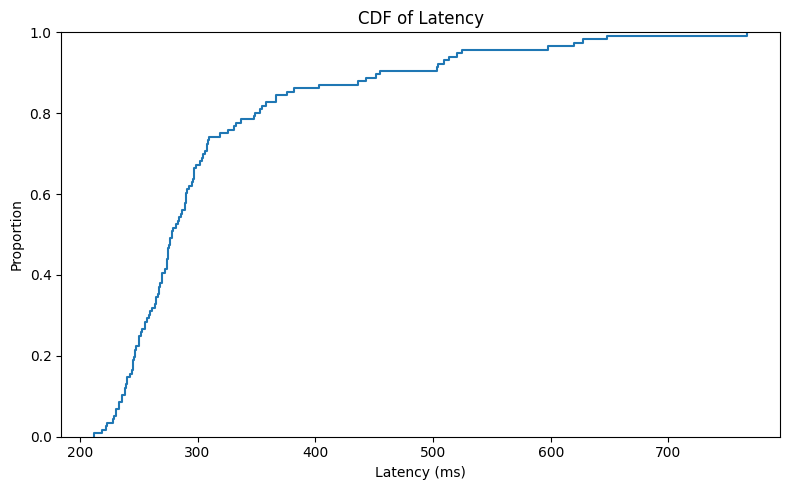

In [9]:
%matplotlib inline

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(f"./npf-out/{now}.csv")

# fig, ax = plt.subplots(figsize=(8, 5))
# sns.lineplot(
#     data=df,
#     x="ADDITIONAL_DATA_SIZE",
#     y="y_LATENCY",
#     markers=True,
#     errorbar="sd",
#     ax=ax,
# )
# ax.set_xlabel("Additional Data Size")
# ax.set_ylabel("Latency (ms)")
# ax.set_title("Latency vs Additional Data Size")
# plt.tight_layout()
# plt.savefig("latency_vs_size.png", dpi=150)
# plt.show()

# plt.figure()
fig, ax = plt.subplots(figsize=(8, 5))
sns.ecdfplot(data=df, x="y_LATENCY", ax=ax)
ax.set_xlabel("Latency (ms)")
ax.set_title("CDF of Latency")
plt.tight_layout()
# plt.savefig("latency_cdf.png", dpi=150)
plt.show()

### Dumping FRRouting config + tunnels

In [14]:
from pathlib import Path
from datetime import datetime
import subprocess

DUMP_ROOT = Path("./node_config_dumps") / datetime.now().strftime("%Y%m%d_%H%M%S")
DUMP_ROOT.mkdir(parents=True, exist_ok=True)

ROLES_TO_DUMP = ["router"]
COMMANDS = {
    "frr.conf.txt": "sudo cat /etc/frr/frr.conf",
    "frr.daemons.txt": "sudo cat /etc/frr/daemons",
    "ip_addr.txt": "ip -br addr",
    "ip_route.txt": "ip route show",
    "ip_tunnel.txt": "ip tunnel show",
}

def ssh_capture(host: str, command: str) -> subprocess.CompletedProcess[str]:
    return subprocess.run(
        ["ssh", f"root@{host}", command],
        capture_output=True,
        text=True,
    )

for role in ROLES_TO_DUMP:
    if role not in roles:
        continue

    role_dir = DUMP_ROOT / role
    role_dir.mkdir(parents=True, exist_ok=True)

    for node in roles[role]:
        host = node.address
        node_name = (getattr(node, "alias", host) or host).replace("/", "_")
        node_dir = role_dir / node_name
        node_dir.mkdir(parents=True, exist_ok=True)

        (node_dir / "node.txt").write_text(
            f"role={role}\nalias={getattr(node, 'alias', '')}\naddress={host}\n",
            encoding="utf-8",
        )

        for output_name, cmd in COMMANDS.items():
            result = ssh_capture(host, cmd)
            out_file = node_dir / output_name

            if result.returncode == 0:
                out_file.write_text(result.stdout, encoding="utf-8")
            else:
                out_file.write_text(
                    "\n".join(
                        [
                            f"Command failed with return code {result.returncode}",
                            f"$ {cmd}",
                            "",
                            "STDERR:",
                            result.stderr,
                            "",
                            "STDOUT:",
                            result.stdout,
                        ]
                    ),
                    encoding="utf-8",
                )

        # Keep a raw archive of /etc/frr for post-mortem analysis.
        frr_archive_path = node_dir / "etc_frr.tar.gz"
        with frr_archive_path.open("wb") as archive_file:
            archive_result = subprocess.run(
                ["ssh", "root","@", host, "sudo tar -C /etc -czf - frr"],
                stdout=archive_file,
                stderr=subprocess.PIPE,
            )

        if archive_result.returncode != 0:
            (node_dir / "etc_frr_archive_error.txt").write_text(
                archive_result.stderr.decode("utf-8", errors="replace"),
                encoding="utf-8",
            )

        print(f"Dumped configs for {host} into {node_dir}")

print(f"All node config dumps are available in: {DUMP_ROOT.resolve()}")

Dumped configs for parasilo-14.rennes.grid5000.fr into node_config_dumps/20260406_193842/router/parasilo-14.rennes.grid5000.fr
Dumped configs for econome-10.nantes.grid5000.fr into node_config_dumps/20260406_193842/router/econome-10.nantes.grid5000.fr
All node config dumps are available in: /home/corentin/fcquic_applications_master_thesis/evaluations/grid5000/test_gre_tunnels/node_config_dumps/20260406_193842


### Stopping the current booking

In [15]:
provider.destroy()

INFO     [G5k] Reloading 312062 from nantes                              ]8;id=189530;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=825332;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Reloading 3663895 from rennes                             ]8;id=934226;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=510910;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Killing the job (nantes, 312062)                          ]8;id=372823;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=276714;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#276\276]8;;\

INFO     [G5k] Job killed (nantes, 312062)                               ]8;id=485478;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=341294;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#257\257]8;;\

INFO     [G5k] Killing the job (rennes, 3663895)                         ]8;id=475519;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=981500;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#276\276]8;;\

INFO     [G5k] Job killed (rennes, 3663895)                              ]8;id=799011;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=484447;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#257\257]8;;\